In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [20]:
df = pd.read_csv('../Data/group5-adult.csv')
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,33,Private,362747,Some-college,10,Never-married,Other-service,Not-in-family,Black,Female,0,0,35,United-States,<=50K
1,46,Private,384795,Bachelors,13,Divorced,Prof-specialty,Unmarried,Black,Female,0,0,32,United-States,<=50K
2,46,Private,164682,Assoc-voc,11,Separated,Prof-specialty,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,26,Private,64293,Some-college,10,Never-married,Prof-specialty,Not-in-family,White,Female,0,0,35,United-States,<=50K
4,26,Self-emp-not-inc,384276,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,<=50K


In [21]:
print(f"Dataset Shape: {df.shape}")
print(f"Total Records: {df.shape[0]}")
print(f"Total Features: {df.shape[1]}")

Dataset Shape: (29385, 15)
Total Records: 29385
Total Features: 15


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29385 entries, 0 to 29384
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             29385 non-null  int64 
 1   workclass       29385 non-null  object
 2   fnlwgt          29385 non-null  int64 
 3   education       29385 non-null  object
 4   education-num   29385 non-null  int64 
 5   marital-status  29385 non-null  object
 6   occupation      29385 non-null  object
 7   relationship    29385 non-null  object
 8   race            29385 non-null  object
 9   sex             29385 non-null  object
 10  capital-gain    29385 non-null  int64 
 11  capital-loss    29385 non-null  int64 
 12  hours-per-week  29385 non-null  int64 
 13  native-country  29385 non-null  object
 14  income          29385 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.4+ MB


In [23]:
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,29385.000000,2.938500e+04,29385.000000,29385.000000,29385.000000,29385.000000
mean,38.610856,1.896097e+05,10.084533,1082.623515,87.936124,40.447848
std,13.643457,1.058481e+05,2.575725,7418.557731,404.778611,12.361165
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.176270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.782550e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.368790e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
print("=== Missing values represented as '?' ===")
print(df.isin(['?']).sum())

=== Missing values represented as '?' ===
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [24]:
df.replace('?', np.nan, inplace=True)
print("=== Null values after replacing '?' ===")
print(df.isnull().sum())

=== Null values after replacing '?' ===
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64


In [25]:
print("=== Target Variable Distribution ===")
print(df['income'].value_counts())
print(f"\nClass Balance: {df['income'].value_counts(normalize=True).round(3) * 100}")

=== Target Variable Distribution ===
income
<=50K    22328
>50K      7057
Name: count, dtype: int64

Class Balance: income
<=50K    76.0
>50K     24.0
Name: proportion, dtype: float64


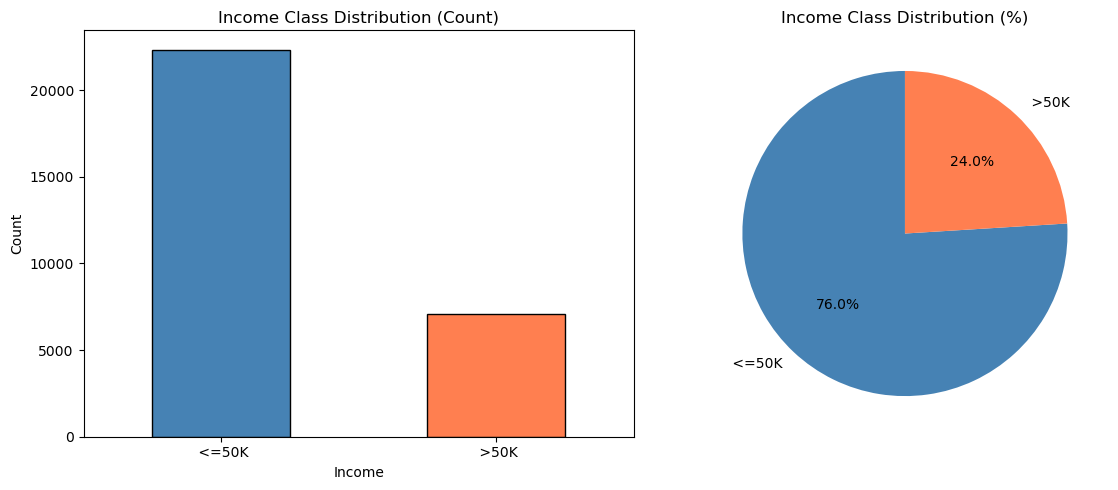

Saved!


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
df['income'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='black')
axes[0].set_title('Income Class Distribution (Count)')
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Count')
axes[0].tick_params(rotation=0)

# Pie chart
df['income'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                  colors=['steelblue', 'coral'], startangle=90)
axes[1].set_title('Income Class Distribution (%)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('data/eda_class_distribution.png', dpi=150)
plt.show()
print("Saved!")

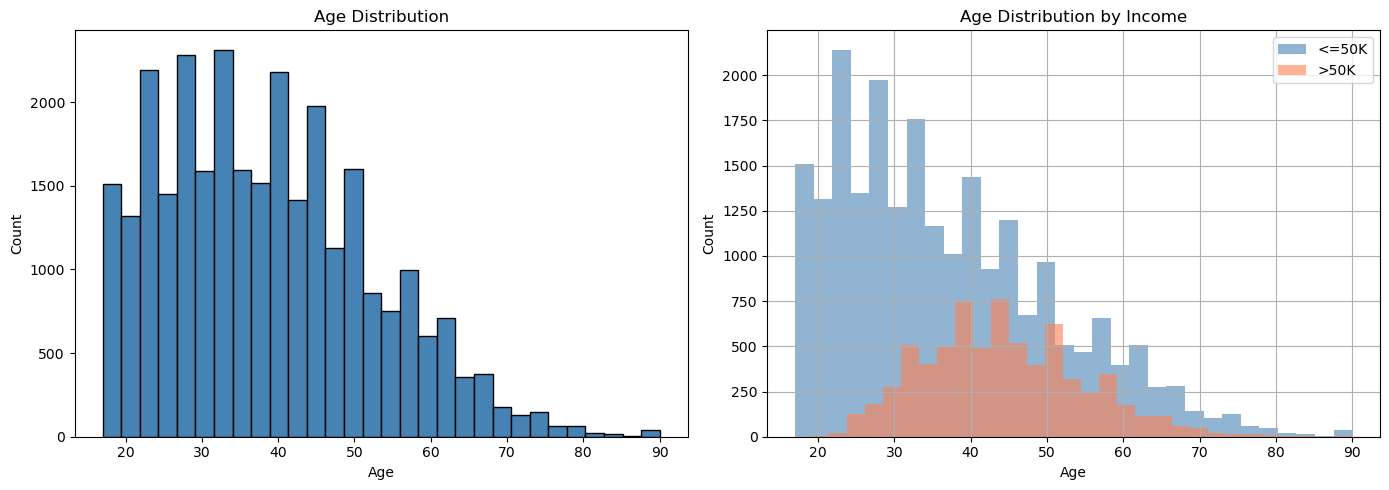

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall age distribution
axes[0].hist(df['age'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

# Age by income
df[df['income'] == ' <=50K']['age'].hist(bins=30, alpha=0.6, color='steelblue', label='<=50K', ax=axes[1])
df[df['income'] == ' >50K']['age'].hist(bins=30, alpha=0.6, color='coral', label='>50K', ax=axes[1])
axes[1].set_title('Age Distribution by Income')
axes[1].set_xlabel('Age')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('data/eda_age_distribution.png', dpi=150)
plt.show()

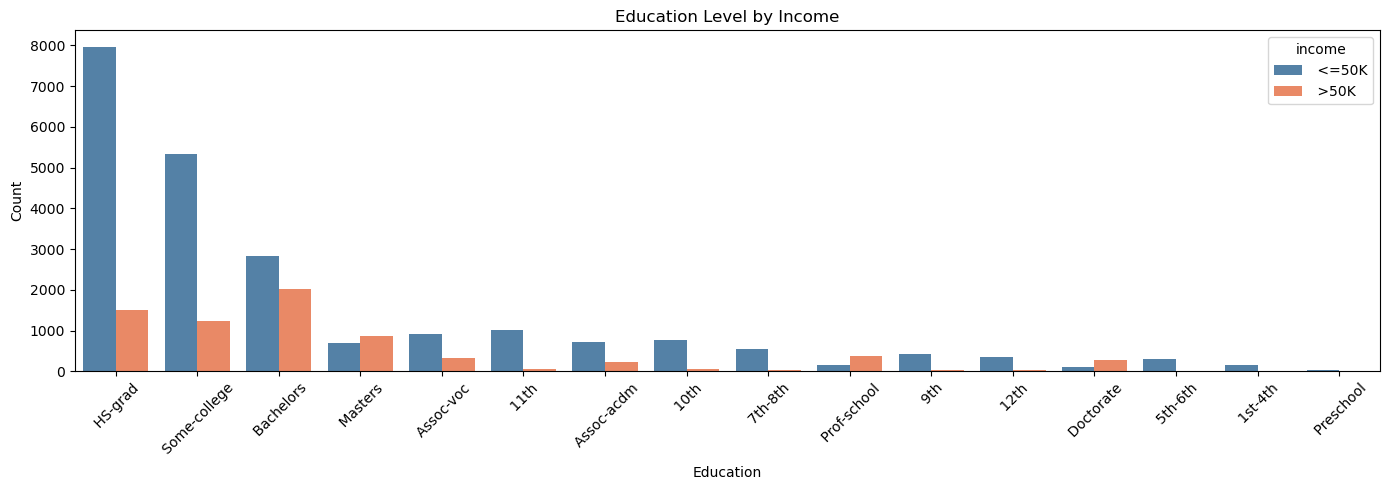

In [29]:
fig, ax = plt.subplots(figsize=(14, 5))
edu_order = df['education'].value_counts().index
sns.countplot(data=df, x='education', hue='income', order=edu_order, ax=ax,
              palette=['steelblue', 'coral'])
ax.set_title('Education Level by Income')
ax.set_xlabel('Education')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('data/eda_education.png', dpi=150)
plt.show()

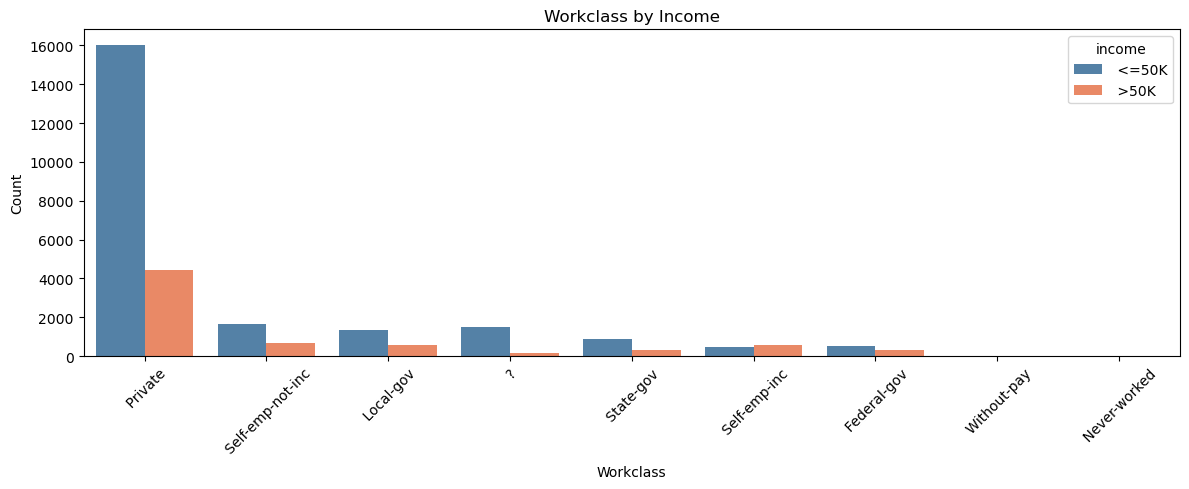

In [30]:
fig, ax = plt.subplots(figsize=(12, 5))
wc_order = df['workclass'].value_counts().index
sns.countplot(data=df, x='workclass', hue='income', order=wc_order, ax=ax,
              palette=['steelblue', 'coral'])
ax.set_title('Workclass by Income')
ax.set_xlabel('Workclass')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('data/eda_workclass.png', dpi=150)
plt.show()

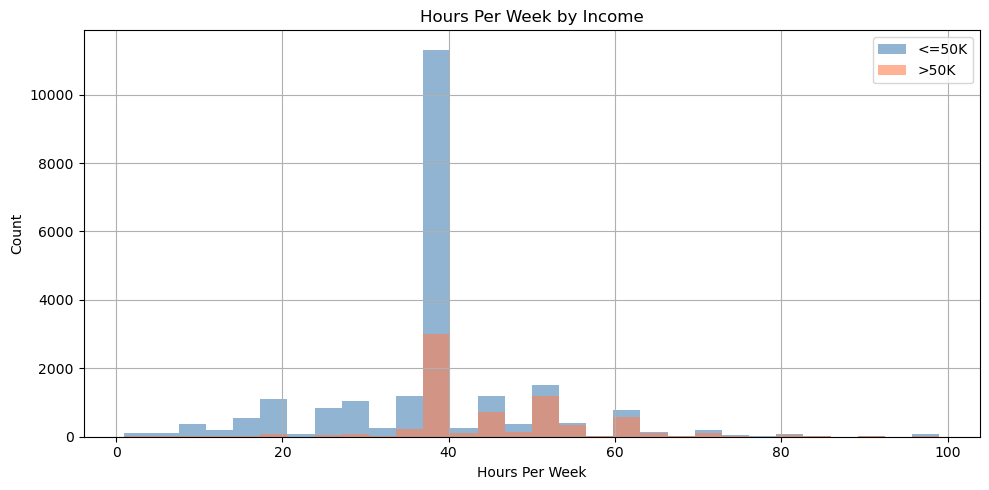

In [31]:
fig, ax = plt.subplots(figsize=(10, 5))
df[df['income'] == ' <=50K']['hours-per-week'].hist(bins=30, alpha=0.6,
                                                     color='steelblue', label='<=50K', ax=ax)
df[df['income'] == ' >50K']['hours-per-week'].hist(bins=30, alpha=0.6,
                                                    color='coral', label='>50K', ax=ax)
ax.set_title('Hours Per Week by Income')
ax.set_xlabel('Hours Per Week')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.savefig('data/eda_hours_per_week.png', dpi=150)
plt.show()

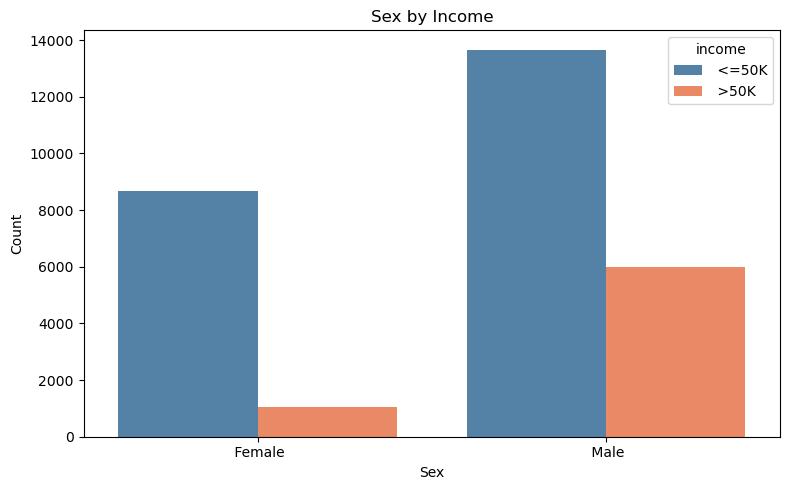

In [32]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='sex', hue='income', palette=['steelblue', 'coral'], ax=ax)
ax.set_title('Sex by Income')
ax.set_xlabel('Sex')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('data/eda_sex.png', dpi=150)
plt.show()

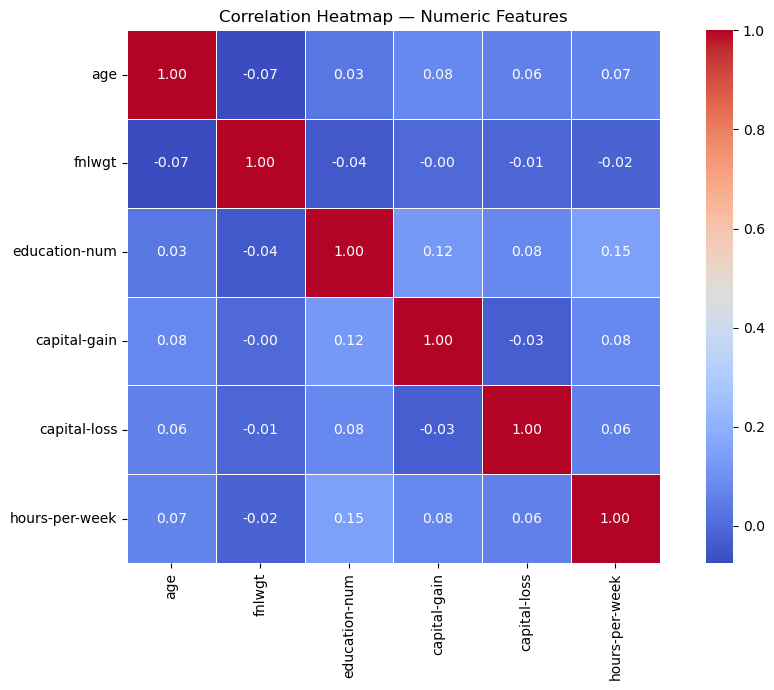

In [33]:
fig, ax = plt.subplots(figsize=(10, 7))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Heatmap — Numeric Features')
plt.tight_layout()
plt.savefig('data/eda_correlation_heatmap.png', dpi=150)
plt.show()

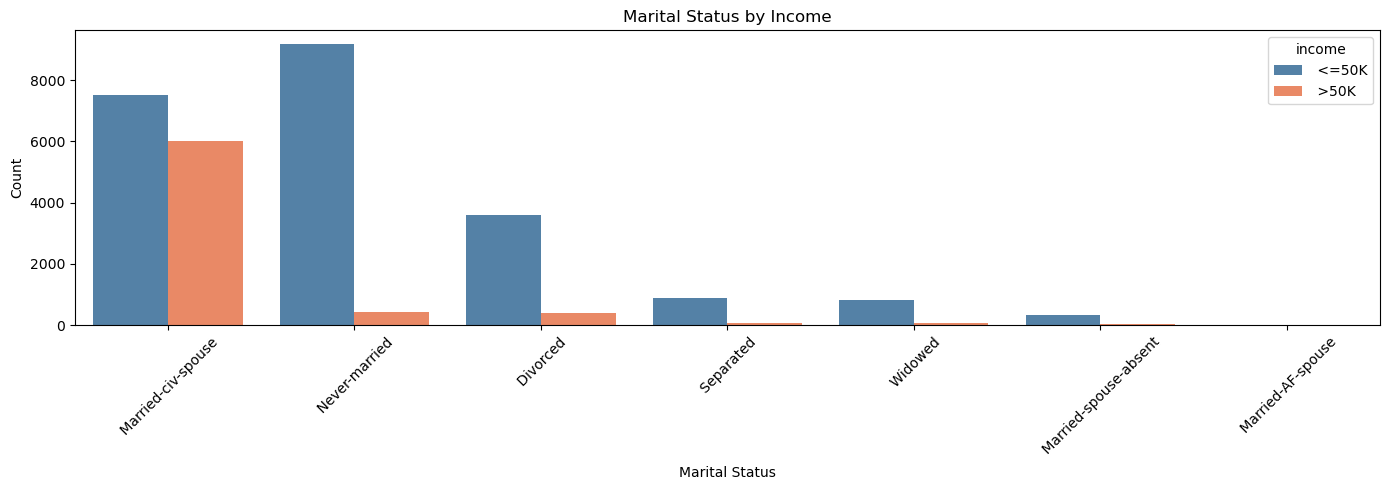

In [34]:
fig, ax = plt.subplots(figsize=(14, 5))
ms_order = df['marital-status'].value_counts().index
sns.countplot(data=df, x='marital-status', hue='income',
              order=ms_order, palette=['steelblue', 'coral'], ax=ax)
ax.set_title('Marital Status by Income')
ax.set_xlabel('Marital Status')
ax.set_ylabel('Count')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('data/eda_marital_status.png', dpi=150)
plt.show()

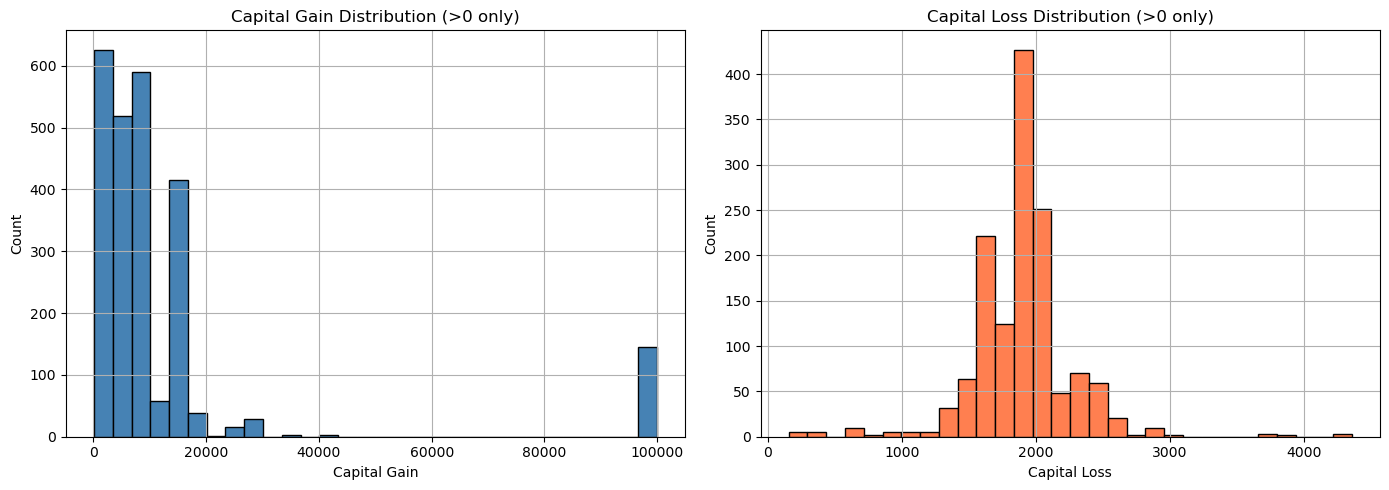

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[df['capital-gain'] > 0]['capital-gain'].hist(bins=30, ax=axes[0],
                                                  color='steelblue', edgecolor='black')
axes[0].set_title('Capital Gain Distribution (>0 only)')
axes[0].set_xlabel('Capital Gain')
axes[0].set_ylabel('Count')

df[df['capital-loss'] > 0]['capital-loss'].hist(bins=30, ax=axes[1],
                                                  color='coral', edgecolor='black')
axes[1].set_title('Capital Loss Distribution (>0 only)')
axes[1].set_xlabel('Capital Loss')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('data/eda_capital.png', dpi=150)
plt.show()

In [36]:
print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)
print(f"Total records         : {df.shape[0]}")
print(f"Total features        : {df.shape[1] - 1}")
print(f"Target classes        : {df['income'].unique()}")
print(f"Class <=50K           : {(df['income'] == ' <=50K').sum()} ({(df['income'] == ' <=50K').mean()*100:.1f}%)")
print(f"Class >50K            : {(df['income'] == ' >50K').sum()} ({(df['income'] == ' >50K').mean()*100:.1f}%)")
print(f"Missing values (NaN)  : {df.isnull().sum().sum()}")
print(f"Numeric features      : {df.select_dtypes(include=np.number).shape[1]}")
print(f"Categorical features  : {df.select_dtypes(include='object').shape[1] - 1}")
print("=" * 50)
print("EDA Complete — all plots saved to notebooks/data/")

EDA SUMMARY
Total records         : 29385
Total features        : 14
Target classes        : [' <=50K' ' >50K']
Class <=50K           : 22328 (76.0%)
Class >50K            : 7057 (24.0%)
Missing values (NaN)  : 0
Numeric features      : 6
Categorical features  : 8
EDA Complete — all plots saved to notebooks/data/
